<a href="https://colab.research.google.com/github/EdgarJason/PraktikumKAL/blob/main/Praktikum_3_EDGAR_JASON_HUSIN_245150201111047.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Praktikum Kecerdasan Artifisial Lanjut


---
## Bab 3. Representasi Data


## Instalasi Library
Jalankan kode berikut untuk memastikan library telah terinstal di Google Colab.

In [60]:
import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import scipy
import sklearn
import csv

print(f'numpy: {np.__version__}')
print(f'pandas: {pd.__version__}')
print(f'matplotlib: {matplotlib.__version__}')
print(f'scipy: {scipy.__version__}')
print(f'sklearn: {sklearn.__version__}')

numpy: 2.0.2
pandas: 2.2.2
matplotlib: 3.10.0
scipy: 1.16.3
sklearn: 1.6.1


## Memuat Dataset
### Memuat Dataset Lokal
Unggah file `kontak.csv` ke Google Colab menggunakan kode berikut:

In [61]:
from google.colab import files

kontak = files.upload()

for fn in kontak.keys():
  print(f'Nama file "{fn}" dengan panjang {len(kontak[fn])} bytes')


Saving kontak.csv to kontak.csv
Nama file "kontak.csv" dengan panjang 113 bytes


### Memuat Dataset dari Internet
Unduh dataset Iris menggunakan wget:

In [62]:
! wget https://dataset-kal.s3.us-east-1.amazonaws.com/iris_missing.csv

--2026-03-17 05:45:13--  https://dataset-kal.s3.us-east-1.amazonaws.com/iris_missing.csv
Resolving dataset-kal.s3.us-east-1.amazonaws.com (dataset-kal.s3.us-east-1.amazonaws.com)... 16.15.199.128, 52.217.132.122, 54.231.139.186, ...
Connecting to dataset-kal.s3.us-east-1.amazonaws.com (dataset-kal.s3.us-east-1.amazonaws.com)|16.15.199.128|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 4593 (4.5K) [text/csv]
Saving to: ‘iris_missing.csv’

iris_missing.csv    100%[===================>]   4.49K  --.-KB/s    in 0s      

2026-03-17 05:45:14 (181 MB/s) - ‘iris_missing.csv’ saved [4593/4593]



### Cek File
Cek file yang telah diunduh atau diunggah menggunakan perintah berikut:

In [63]:
!ls

iris_missing.csv  kontak.csv  sample_data


## Membaca Format CSV
### Menggunakan List

In [64]:
import csv
def csv_list(filename):
  data = []

  with open(filename, mode='r') as csv_file:
    csv_reader = csv.reader (csv_file, delimiter=",")

    for row in csv_reader:
      data.append(row)

  data.pop(0)
  return data

In [65]:
list_kontak = csv_list('kontak.csv')
print(list_kontak)

[['1', ' Achmad Ali', ' 081234'], ['2', ' Budi Utomo', ' 08712333'], ['3', ' Toni Saja', ' 08733311'], ['4', ' Dewi Utami', ' 0851231']]


### Menggunakan Dictionary

In [66]:
import csv
def csv_dict(filename):
  data = []

  with open(filename, mode='r') as csv_file:
    csv_reader = csv.DictReader(csv_file)

    for row in csv_reader:
      data.append(row)

  return data

In [67]:
# Uji fungsi csv_dict
csv_data = csv_dict('kontak.csv')

# Menampilkan hasil pengujian
print("Hasil dari csv_dict:")
for row in csv_data:
  print(row)

Hasil dari csv_dict:
{'NO': '1', ' NAMA': ' Achmad Ali', ' TELEPON': ' 081234'}
{'NO': '2', ' NAMA': ' Budi Utomo', ' TELEPON': ' 08712333'}
{'NO': '3', ' NAMA': ' Toni Saja', ' TELEPON': ' 08733311'}
{'NO': '4', ' NAMA': ' Dewi Utami', ' TELEPON': ' 0851231'}


## Membaca CSV menggunakan Pandas

In [68]:
iris_df = pd.read_csv('/content/iris_missing.csv')
iris_df.head()

,sepal_length,sepal_width,petal_length,petal_width,Species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,0.0,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


## Meringkas Kumpulan Data

In [69]:
print(iris_df.head(6)) # menampilkan 6 data pertama
print(iris_df.shape) # menampilkan dimensi dataframe
print(iris_df.describe())
# menampilkan distribusi data

print(iris_df.groupby('Species').size()) # menampilkan banyak data per kelas

   sepal_length  sepal_width  petal_length  petal_width      Species
0           5.1          3.5           1.4          0.2  Iris-setosa
1           4.9          3.0           1.4          0.2  Iris-setosa
2           0.0          3.2           1.3          0.2  Iris-setosa
3           4.6          3.1           1.5          0.2  Iris-setosa
4           5.0          3.6           1.4          0.2  Iris-setosa
5           5.4          3.9           1.7          0.4  Iris-setosa
(150, 5)
       sepal_length  sepal_width  petal_length  petal_width
count    150.000000   150.000000    150.000000   150.000000
mean       5.731333     2.988000      3.684667     1.147333
std        1.153352     0.604893      1.826675     0.773790
min        0.000000     0.000000      0.000000     0.000000
25%        5.100000     2.800000      1.500000     0.225000
50%        5.800000     3.000000      4.300000     1.300000
75%        6.400000     3.300000      5.100000     1.800000
max        7.900000     4.40

## Visualisasi Kumpulan Data
### Box Plot

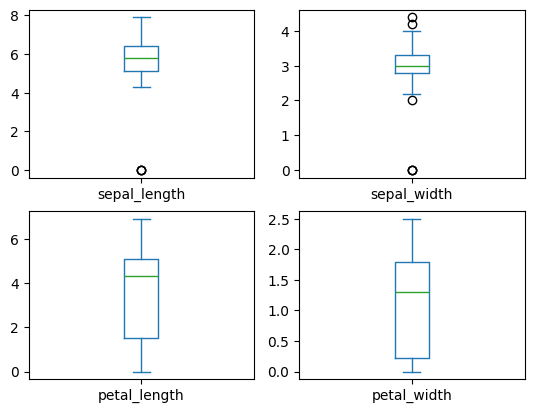

In [70]:
from matplotlib import pyplot
iris_df.plot(kind='box', subplots=True, layout=(2,2), sharex=False, sharey=False)
pyplot.show()

pyplot.show()

### Histogram

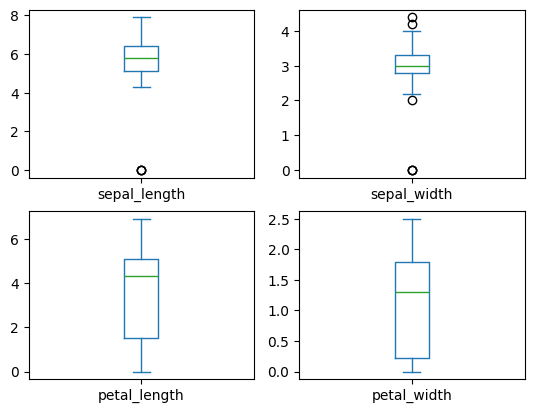

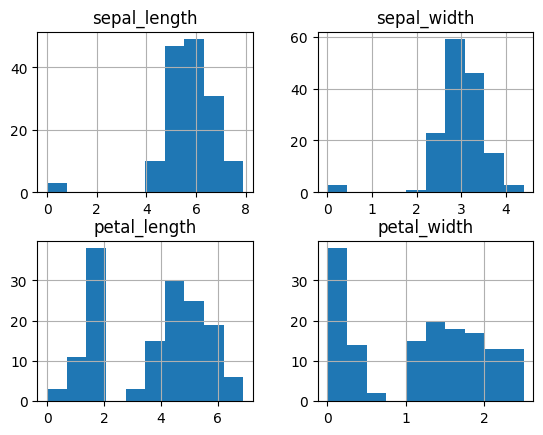

In [71]:
from matplotlib import pyplot
iris_df.plot(kind='box', subplots=True, layout=(2,2), sharex=False, sharey=False)
pyplot.show()

iris_df.hist()
pyplot.show()

### Scatter Plot Matrix

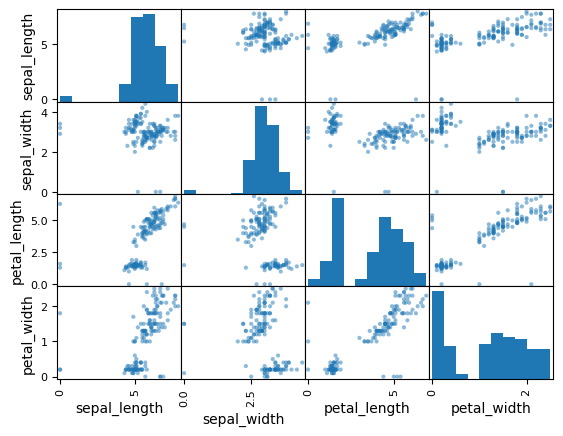

In [72]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

scatter_matrix(iris_df)
plt.show()

## Tugas
1. Download Glass dataset dari https://archive.ics.uci.edu/dataset/42/glass+identification
2. Masukkan data Glass ke dataframe menggunakan Pandas.
3. Tampilkan 10 data pertama.
4. Hitung rata-rata nilai per variabel untuk setiap data.
5. Hitung rata-rata nilai per variabel dikelompokkan berdasarkan `Type`.
6. Buatlah plot bertipe 'line' untuk masing-masing variabelnya menggunakan Pandas Plot.

In [73]:
#IMPORT DAN DOWNLOAD DATASET

import pandas as pd
import matplotlib.pyplot as plt

!wget https://archive.ics.uci.edu/ml/machine-learning-databases/glass/glass.data

--2026-03-17 05:45:16--  https://archive.ics.uci.edu/ml/machine-learning-databases/glass/glass.data
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘glass.data’

glass.data              [ <=>                ]  11.62K  --.-KB/s    in 0s      

2026-03-17 05:45:16 (141 MB/s) - ‘glass.data’ saved [11903]



In [74]:
#MEMASUKKAN DATA FLASS KE DATAFRAME

column_names = ['Id', 'RI', 'Na', 'Mg', 'Al', 'Si', 'K', 'Ca', 'Ba', 'Fe', 'Type']
glass_df = pd.read_csv('glass.data', names=column_names)

In [75]:
#10 DATA PERTAMA

print("--- 10 Data Pertama ---")
print(glass_df.head(10))

--- 10 Data Pertama ---
   Id       RI     Na    Mg    Al     Si     K    Ca   Ba    Fe  Type
0   1  1.52101  13.64  4.49  1.10  71.78  0.06  8.75  0.0  0.00     1
1   2  1.51761  13.89  3.60  1.36  72.73  0.48  7.83  0.0  0.00     1
2   3  1.51618  13.53  3.55  1.54  72.99  0.39  7.78  0.0  0.00     1
3   4  1.51766  13.21  3.69  1.29  72.61  0.57  8.22  0.0  0.00     1
4   5  1.51742  13.27  3.62  1.24  73.08  0.55  8.07  0.0  0.00     1
5   6  1.51596  12.79  3.61  1.62  72.97  0.64  8.07  0.0  0.26     1
6   7  1.51743  13.30  3.60  1.14  73.09  0.58  8.17  0.0  0.00     1
7   8  1.51756  13.15  3.61  1.05  73.24  0.57  8.24  0.0  0.00     1
8   9  1.51918  14.04  3.58  1.37  72.08  0.56  8.30  0.0  0.00     1
9  10  1.51755  13.00  3.60  1.36  72.99  0.57  8.40  0.0  0.11     1


In [76]:
#RATA RATA PER VARIABEL UNTUK SELURUH DATA

print("\n--- Rata-rata per Variabel (Seluruh Data) ---")
print(glass_df.mean())


--- Rata-rata per Variabel (Seluruh Data) ---
Id      107.500000
RI        1.518365
Na       13.407850
Mg        2.684533
Al        1.444907
Si       72.650935
K         0.497056
Ca        8.956963
Ba        0.175047
Fe        0.057009
Type      2.780374
dtype: float64


In [77]:
#RATA RATA NILAI PER VARIABEL DIKELOMPOKKAN BERDASARKAN TYPE

print("\n--- Rata-rata per Variabel Berdasarkan Type ---")
print(glass_df.groupby('Type').mean())


--- Rata-rata per Variabel Berdasarkan Type ---
         Id        RI         Na        Mg        Al         Si         K  \
Type                                                                        
1      35.5  1.518718  13.242286  3.552429  1.163857  72.619143  0.447429   
2     108.5  1.518619  13.111711  3.002105  1.408158  72.598026  0.521053   
3     155.0  1.517964  13.437059  3.543529  1.201176  72.404706  0.406471   
5     170.0  1.518928  12.827692  0.773846  2.033846  72.366154  1.470000   
6     181.0  1.517456  14.646667  1.305556  1.366667  73.206667  0.000000   
7     200.0  1.517116  14.442069  0.538276  2.122759  72.965862  0.325172   

             Ca        Ba        Fe  
Type                                 
1      8.797286  0.012714  0.057000  
2      9.073684  0.050263  0.079737  
3      8.782941  0.008824  0.057059  
5     10.123846  0.187692  0.060769  
6      9.356667  0.000000  0.000000  
7      8.491379  1.040000  0.013448  


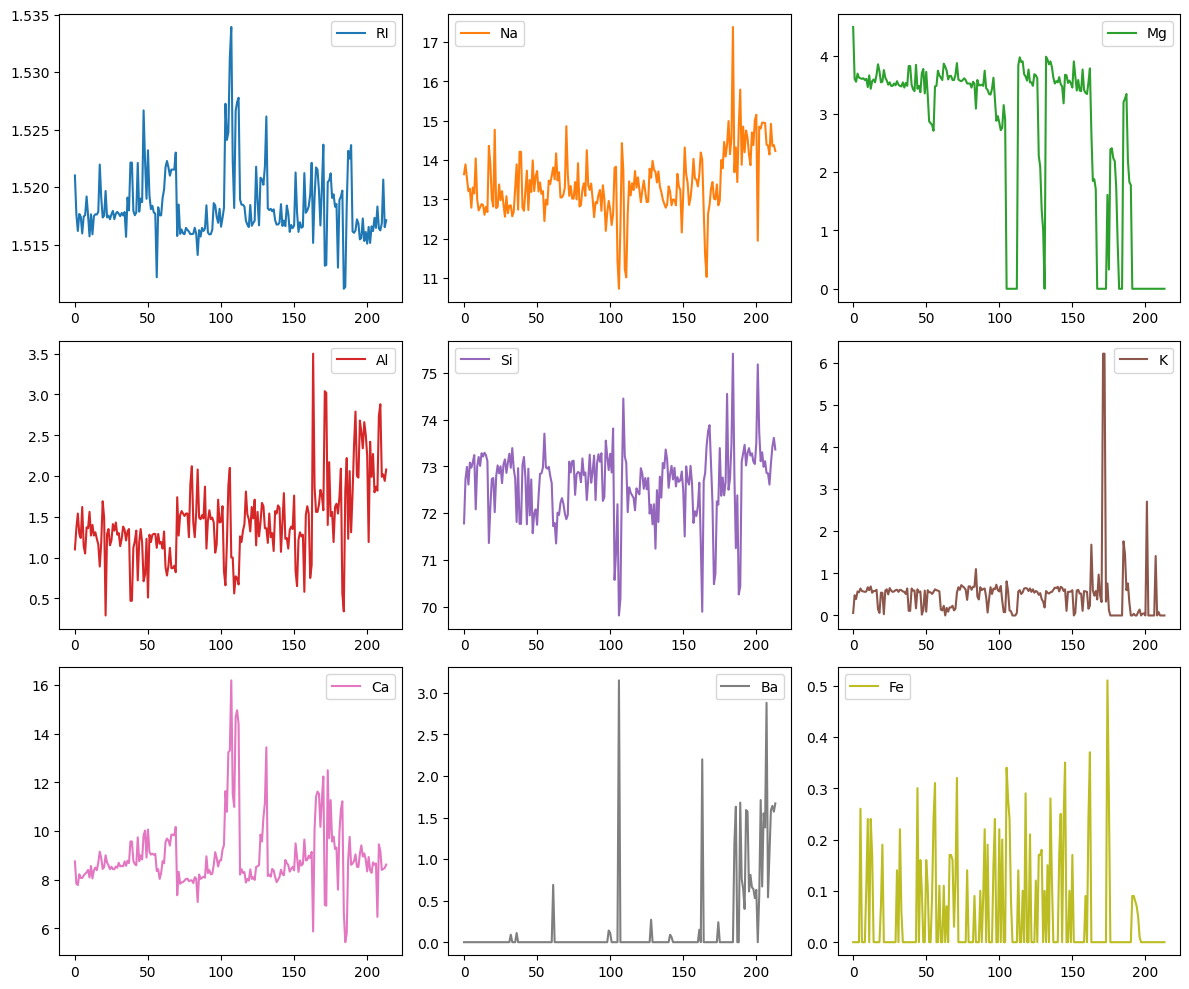

In [78]:
#PLOT BERTYPE LINE UNTUK MASING-MASING VARIABEL MENGGUNAKAN PANDAS PLOT

glass_df.drop(['Id', 'Type'], axis=1).plot(kind='line', subplots=True, layout=(3,3), figsize=(12,10), sharex=False)
plt.tight_layout()
plt.show()

Penjelasan
---
Kode yang telah dijalankan tersebut merupakan urutan pemrosesan data mulai dari tahap pengambilan data mentah hingga visualisasi akhir. Proses diawali dengan mengunduh file dataset dari repositori UCI menggunakan perintah wget dan memuatnya ke dalam struktur DataFrame melalui pustaka Pandas. Karena dataset ini tidak memiliki baris judul di dalam file aslinya, nama variabel seperti indeks bias (RI) dan berbagai unsur kimia seperti Natrium (Na) serta Magnesium (Mg) didefinisikan secara manual agar data lebih mudah diinterpretasikan. Setelah data masuk ke sistem, perintah head digunakan untuk memverifikasi bahwa data terbaca dengan benar, diikuti dengan perhitungan rata rata untuk melihat kecenderungan nilai pada setiap parameter kimia di seluruh sampel yang ada.

Hasil analisa statistik menunjukkan perbedaan komposisi yang cukup signifikan ketika data dikelompokkan berdasarkan variabel Type. Melalui fungsi groupby, kita dapat melihat bahwa jenis kaca tertentu memiliki kadar unsur kimia yang berbeda, misalnya kadar Magnesium atau Aluminium yang lebih tinggi pada tipe kaca jendela dibandingkan kaca meja atau botol. Hal ini menandakan bahwa komposisi kimia adalah faktor penentu utama dalam klasifikasi jenis kaca. Terakhir, visualisasi dengan plot tipe line memberikan gambaran mengenai sebaran nilai di setiap baris data. Dari grafik tersebut, terlihat kalau ada fluktuasi nilai yang menunjukkan keberagaman data atau variasi dalam setiap sampel, yang membantu kita identifikasi apakah terdapat pola tertentu atau nilai yang sangat berbeda jauh dari rata rata pada variabel tertentu.